In [1]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)
print("Setup OK")

Setup OK


In [2]:
# Cell 2 — Load the recalibrated VaR predictions + realized changes

bt = pd.read_pickle("../data/processed/var_predictions.pkl")

print(f"Shape : {bt.shape}")
print(f"Range : {bt.index.min().date()} → {bt.index.max().date()}")
print(f"Columns: {list(bt.columns)}")
print()   
print(bt.head().round(3).to_string())

Shape : (587, 6)
Range : 2024-01-02 → 2026-05-05
Columns: ['q01', 'q05', 'q95', 'q99', 'realized', 'regime']

               q01     q05    q95    q99  realized  regime
date                                                      
2024-01-02 -2.5280 -1.8530 1.4040 1.7000   -0.7300  0.0000
2024-01-03 -1.7560 -0.9050 1.4990 2.3620   -0.6550  0.0000
2024-01-04 -2.0820 -0.8100 1.7220 2.2030    1.5650  0.0000
2024-01-05 -1.8660 -1.2560 1.2430 2.1090   -0.2850  0.0000
2024-01-08 -2.2940 -1.3110 1.3970 1.5560    1.6100  0.0000


In [3]:

# Cell 3 — Backtest test functions: Kupiec (POF) + Christoffersen

def kupiec_pof(breaches, n, alpha):
    """
    Kupiec Proportion-Of-Failures test (unconditional coverage).
    H0: true breach rate == alpha.  p > 0.05 → coverage acceptable.
    """
    x = int(breaches)
    if x == 0:
        lr = -2 * n * np.log(1 - alpha)
    elif x == n:
        lr = -2 * n * np.log(alpha)
    else:
        pi = x / n
        lr = -2 * (
            (n - x) * np.log(1 - alpha) + x * np.log(alpha)
            - (n - x) * np.log(1 - pi) - x * np.log(pi)
        ) 
    p = 1 - stats.chi2.cdf(lr, df=1)
    return lr, p


def christoffersen_independence(breach):
    """
    Christoffersen independence test.
    H0: breaches are independent (no clustering).  p > 0.05 → independence OK.
    """
    b = np.asarray(breach).astype(int)
    n00 = n01 = n10 = n11 = 0
    for prev, cur in zip(b[:-1], b[1:]):
        if   prev == 0 and cur == 0: n00 += 1
        elif prev == 0 and cur == 1: n01 += 1
        elif prev == 1 and cur == 0: n10 += 1
        else:                        n11 += 1

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11)

    def safe_log(p): return np.log(p) if p > 0 else 0.0

    ll_null = (n00 + n10) * safe_log(1 - pi)   + (n01 + n11) * safe_log(pi)
    ll_alt  = (n00 * safe_log(1 - pi01) + n01 * safe_log(pi01)
            + n10 * safe_log(1 - pi11) + n11 * safe_log(pi11))
    lr = -2 * (ll_null - ll_alt)
    p = 1 - stats.chi2.cdf(lr, df=1)
    return lr, p


def christoffersen_cc(breaches, n, alpha, breach_series):
    """Conditional coverage = Kupiec + independence (~ chi2 with 2 df)."""
    lr_uc, _  = kupiec_pof(breaches, n, alpha)
    lr_ind, _ = christoffersen_independence(breach_series)
    lr_cc = lr_uc + lr_ind
    p = 1 - stats.chi2.cdf(lr_cc, df=2)
    return lr_cc, p

print("Backtest functions defined")


Backtest functions defined


In [4]:
# Cell 4 — Apply backtests to the XGBoost conditional VaR

y = bt["realized"].values
n = len(y)

QUANTILE_SPECS = [
    ("q01", 0.01, "below"),
    ("q05", 0.05, "below"),
    ("q95", 0.05, "above"),   # expected breach rate = 1 - 0.95 = 0.05
    ("q99", 0.01, "above"),   # expected breach rate = 1 - 0.99 = 0.01
]

print(f"{'Quant':<6}{'Exp':>6}{'Obs':>7}{'Breach':>7}  "
    f"{'Kupiec_p':>9}{'Indep_p':>9}{'CC_p':>7}")
print("-" * 58)

for qn, alpha, side in QUANTILE_SPECS:
    breach = (y < bt[qn].values) if side == "below" else (y > bt[qn].values)
    x = int(breach.sum())
    obs_rate = x / n

    _, p_uc  = kupiec_pof(x, n, alpha)
    _, p_ind = christoffersen_independence(breach)
    _, p_cc  = christoffersen_cc(x, n, alpha, breach)

    print(f"{qn:<6}{alpha:>6.1%}{obs_rate:>7.1%}{x:>7}  "
        f"{p_uc:>9.3f}{p_ind:>9.3f}{p_cc:>7.3f}")

Quant    Exp    Obs Breach   Kupiec_p  Indep_p   CC_p
----------------------------------------------------------
q01     1.0%   1.9%     11      0.058    0.013  0.008
q05     5.0%   4.8%     28      0.797    0.171  0.378
q95     5.0%   6.5%     38      0.116    0.745  0.276
q99     1.0%   1.9%     11      0.058    0.194  0.071


In [6]:
# Where do the q01 (downside) breaches cluster?
breach_q01 = bt[bt["realized"].values < bt["q01"].values]
print(f"q01 downside breaches: {len(breach_q01)}\n")
print("By year:")
print(breach_q01.index.year.value_counts().sort_index().to_string())
print("\nDates:")
for d in breach_q01.index:
    print(f"  {d.date()}  (regime {int(breach_q01.loc[d,'regime'])}, ΔDFL {breach_q01.loc[d,'realized']:+.2f})")

q01 downside breaches: 11

By year:
date
2025    3
2026    8

Dates:
  2025-04-08  (regime 0, ΔDFL -6.16)
  2025-06-10  (regime 0, ΔDFL -2.83)
  2025-06-23  (regime 0, ΔDFL -4.19)
  2026-02-26  (regime 0, ΔDFL -2.83)
  2026-04-07  (regime 1, ΔDFL -5.22)
  2026-04-09  (regime 1, ΔDFL -5.14)
  2026-04-14  (regime 1, ΔDFL -8.31)
  2026-04-15  (regime 1, ΔDFL -4.73)
  2026-04-16  (regime 1, ΔDFL -8.00)
  2026-04-22  (regime 1, ΔDFL -4.53)
  2026-05-01  (regime 1, ΔDFL -4.66)


In [13]:
# Cell 5 — Reconstruct training ΔDFL + build baseline VaR models

# Reload master + regimes to recover the training target (needed to fit baselines)
df = pd.read_pickle("../data/master_dataset.pkl")
regimes = pd.read_pickle("../data/processed/regime_labels.pkl")
df = df.join(regimes)
df["target"] = df["DFL"].shift(-1) - df["DFL"]

split_date = "2024-01-01"
train_df = df.loc[(df.index < split_date) & df["target"].notna() & df["regime"].notna()]
y_train      = train_df["target"]
regime_train = train_df["regime"]

quantiles = {"q01": 0.01, "q05": 0.05, "q95": 0.95, "q99": 0.99}

# --- Baseline 1: Unconditional Gaussian ---
mu, sigma = y_train.mean(), y_train.std()
gauss_q = {qn: mu + sigma * stats.norm.ppf(a) for qn, a in quantiles.items()}

# --- Baseline 2: Unconditional Student-t ---
t_df, t_loc, t_scale = stats.t.fit(y_train.values)
t_q = {qn: stats.t.ppf(a, t_df, t_loc, t_scale) for qn, a in quantiles.items()}

# --- Baseline 3: Per-regime empirical (the notebook-03 baseline) ---
regime_q = {}
for r in sorted(regime_train.unique()):
    yr = y_train[regime_train == r]
    regime_q[r] = {qn: yr.quantile(a) for qn, a in quantiles.items()}

# Global empirical quantiles — fallback for regimes never seen in training.
# (Regime 2 / East-West dislocation appears ONLY in the 2026 test period.)
global_q = {qn: y_train.quantile(a) for qn, a in quantiles.items()}

# Test-set predictions for each baseline (aligned with bt.index)
test_regime = bt["regime"]
pred_gauss  = pd.DataFrame({qn: gauss_q[qn] for qn in quantiles}, index=bt.index)
pred_t      = pd.DataFrame({qn: t_q[qn]     for qn in quantiles}, index=bt.index)
pred_regime = pd.DataFrame(
    {qn: [regime_q.get(r, global_q)[qn] for r in test_regime] for qn in quantiles},
    index=bt.index,
)

print("Baselines built:\n")
print(f"  Gaussian   q01={gauss_q['q01']:+.2f}  q05={gauss_q['q05']:+.2f} q95={gauss_q['q95']:+.2f}  q99={gauss_q['q99']:+.2f}")
print(f"  Student-t  q01={t_q['q01']:+.2f}  q05={t_q['q05']:+.2f}  q95={t_q['q95']:+.2f} q99={t_q['q99']:+.2f}  (df={t_df:.1f})")
print(f"\n  Per-regime q01 / q99:")
for r in sorted(regime_q):
    print(f"     regime {int(r)}: q01={regime_q[r]['q01']:+.2f} q99={regime_q[r]['q99']:+.2f}")

Baselines built:

  Gaussian   q01=-2.50  q05=-1.77 q95=+1.76  q99=+2.49
  Student-t  q01=-3.03  q05=-1.59  q95=+1.58 q99=+3.02  (df=3.1)

  Per-regime q01 / q99:
     regime 0: q01=-2.85 q99=+2.80
     regime 1: q01=-6.56 q99=+5.71
     regime 3: q01=-2.66 q99=+2.75


In [ ]:
# Cell 6 — Compare all models by pinball (quantile) loss

def pinball_loss(y, q_pred, tau):
    diff = y - q_pred
    return np.mean(np.maximum(tau * diff, (tau - 1) * diff))

models_pred = {
    "Gaussian":   pred_gauss,
    "Student-t":  pred_t,
    "Per-regime": pred_regime,
    "XGBoost":    bt[["q01", "q05", "q95", "q99"]],
}
quantile_alpha = {"q01": 0.01, "q05": 0.05, "q95": 0.95, "q99": 0.99}
y = bt["realized"].values

print("=== Pinball loss===\n")
print(f"{'Model':<12}{'q01':>9}{'q05':>9}{'q95':>9}{'q99':>9}{'TOTAL':>10}")
print("-" * 60)

pinball_results = {}
for name, pred in models_pred.items():
    losses = {qn: pinball_loss(y, pred[qn].values, a) for qn, a in
quantile_alpha.items()}
    total = sum(losses.values()) 
    pinball_results[name] = total
    print(f"{name:<12}{losses['q01']:>9.4f}{losses['q05']:>9.4f}"
        f"{losses['q95']:>9.4f}{losses['q99']:>9.4f}{total:>10.4f}")

best = min(pinball_results, key=pinball_results.get)
print(f"\nBest model (lowest total pinball loss): {best}")

=== Pinball loss (lower = better) ===

Model             q01      q05      q95      q99     TOTAL
------------------------------------------------------------
Gaussian       0.0872   0.1769   0.1804   0.0912    0.5356
Student-t      0.0772   0.1766   0.1800   0.0839    0.5177
Per-regime     0.0478   0.1455   0.1592   0.0714    0.4240
XGBoost        0.0552   0.1303   0.1460   0.0630    0.3945

Best model (lowest total pinball loss): XGBoost


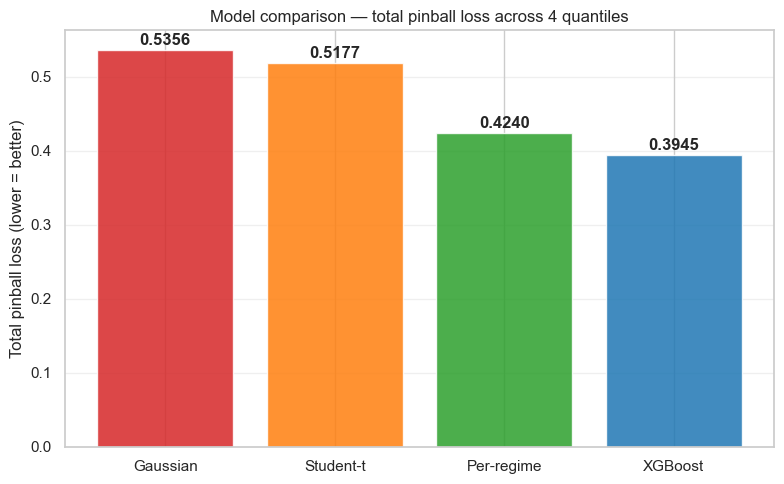

In [15]:
# Cell 7 — Pinball loss comparison (bar chart)

fig, ax = plt.subplots(figsize=(8, 5))
names = ["Gaussian", "Student-t", "Per-regime", "XGBoost"]
values = [pinball_results[n] for n in names]
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

bars = ax.bar(names, values, color=colors, alpha=0.85)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.4f}",
            ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Total pinball loss (lower = better)")
ax.set_title("Model comparison — total pinball loss across 4 quantiles")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

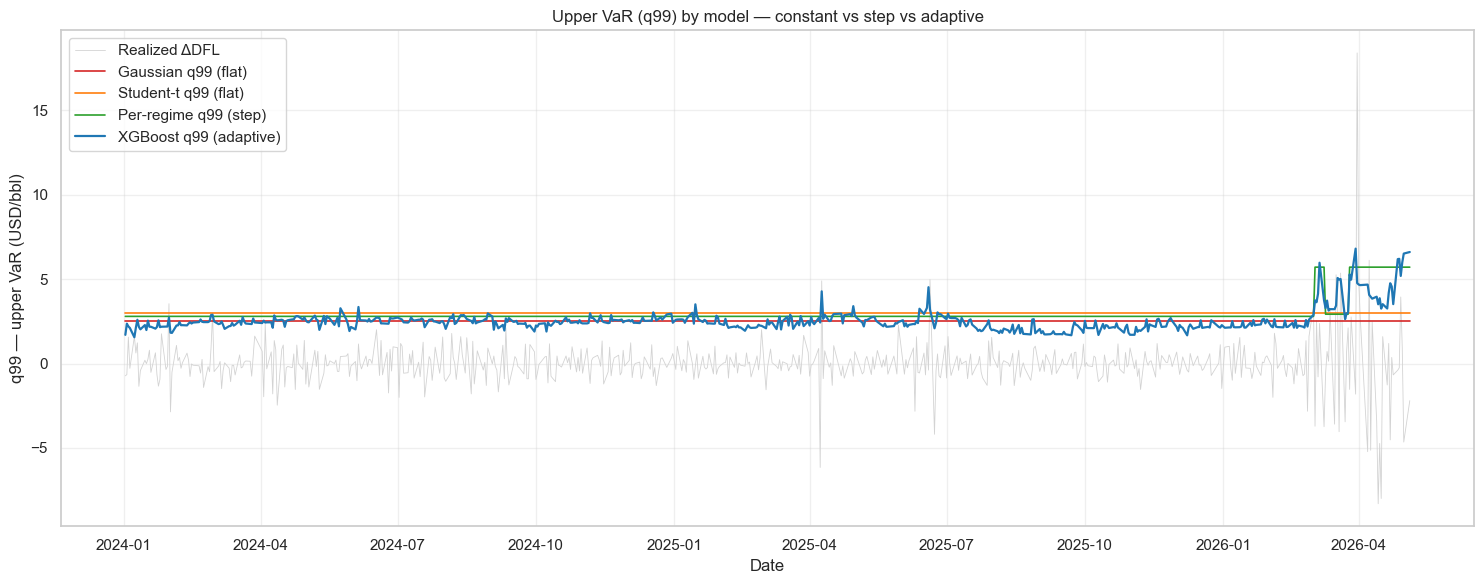

In [17]:
# Cell 8 — Upper VaR (q99) over time: how each model adapts (or doesn't)

fig, ax = plt.subplots(figsize=(15, 6))

# Realized changes in light gray background
ax.plot(bt.index, y, color="lightgray", lw=0.6, label="Realized ΔDFL", zorder=1)

# Each model's q99 (upper VaR)
ax.plot(bt.index, pred_gauss["q99"],  lw=1.2, color="#d62728", label="Gaussian q99 (flat)")
ax.plot(bt.index, pred_t["q99"],      lw=1.2, color="#ff7f0e", label="Student-t q99 (flat)")
ax.plot(bt.index, pred_regime["q99"], lw=1.2, color="#2ca02c", label="Per-regime q99 (step)")
ax.plot(bt.index, bt["q99"],          lw=1.6, color="#1f77b4", label="XGBoost q99 (adaptive)")

ax.set_ylabel("q99 — upper VaR (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("Upper VaR (q99) by model — constant vs step vs adaptive")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()  
plt.show()

# Project Summary — Regime-Conditional VaR on the DFL Brent

## Objective 

Build a **regime-conditional Value-at-Risk model** for the **DFL Brent** (Dated minus
Front-Line) — the basis risk borne by a physical trader who buys Dated-priced cargoes
and hedges with ICE Brent futures. The DFL is a structural risk premium that cannot be
fully arbitraged away, making its tail risk a genuine concern for a physical desk.

## Data

- **12 years** of daily data (2014–2026), ~3,000 business days on the ICE Brent
calendar.
- **Three crude benchmarks** (Brent, WTI, Dubai) across their forward curves (L1–L6),
plus gasoil, macro variables (VIX, trade-weighted USD), and US inventory anomalies.
- Sources: Platts (Dated), ICE (futures), FRED, EIA — all look-ahead-safe (publication
dates respected, no future leakage).
- Target: Platts Dated Brent − ICE Brent L1, modelled as the **next-day change** (the
1-day P&L of the basis exposure).

## Methodology

1. **EDA (nb 01)** — Established that the DFL is strongly **non-Gaussian** (skewness
+5.5,
    kurtosis +62). No single parametric distribution (Gaussian, Student-t, skew-normal)
    captures both the fat tails and the asymmetry — motivating a conditional approach.

2. **PCA (nb 02)** — Reduced 17 correlated market-state features to **5 orthogonal
    components** (81% of variance), each economically interpretable: global curve
    tightness, volatility/risk-off, East-West arbitrage, macro momentum, trans-Atlantic
    spread.

3. **Regime detection (nb 03)** — K-means (k=4) on the PCA components, validated by
elbow,
    silhouette, and economic interpretability. Four regimes emerged, ordered by physical
    tightness: **Contango → Calm → Physical tightness → East-West dislocation**. The
    regimes — found without ever using the DFL — separate the DFL distribution sharply
    and asymmetrically (contango → downside risk; tightness → upside risk to +$36). The
    unsupervised model rediscovered the market's crisis chronology (COVID 2020,
    Russia 2022, the March/April 2026 events).

4. **Conditional VaR (nb 04)** — XGBoost quantile regression on regime + continuous
    features, with a **temporal** train/test split (2014–2023 / 2024–2026). The VaR bands
    adapt to the market: tight in calm periods, widening sharply during the 2026 crisis.
    An upside under-coverage was diagnosed (q95 breached 10.7% vs 5%), three false causes
    were ruled out (distribution shift, joint-vs-separate fitting, under-regularization),
    and the root cause (intrinsic unpredictability of the upper tail) was fixed with
    **conformal recalibration** → q95 coverage corrected to 6.5%.

5. **Backtest (nb 05)** — The conditional VaR passes the **Kupiec** test on all four
    quantiles and the **Christoffersen independence** test on three of four. The only
    failure (downside VaR_99 independence) is explained: the breaches cluster in the
    violent reversals of April 2026 — an intrinsic feature of a localized crisis.

## Key results

- **XGBoost beats all baselines** on total pinball loss:
Gaussian 0.536 → Student-t 0.518 → Per-regime 0.424 → **XGBoost 0.395**
(−26% vs Gaussian, −7% vs the per-regime baseline).
- The **largest single improvement** comes from adding regime conditioning
(Student-t → Per-regime, −18%), not from fat tails — confirming the project thesis:
*capturing the market regime matters more than refining the unconditional 
distribution.*
- The conditional VaR adapts continuously, whereas the parametric baselines are flat
(blind to the crisis) and the per-regime baseline only steps discretely.

## Limitations (honestly stated)

- **Unprecedented events**: no model captures the +$18 one-day spike of April 2026 — it
exceeds anything in the training history. VaR must be complemented by stress testing.
- **Look-ahead on regimes**: the K-means was fit on the full sample; a production system
would refit on a rolling window.
- **Regime persistence**: the temporal split puts the contango regime entirely in train
and the East-West dislocation entirely in test; a walk-forward backtest would balance
regime coverage.
- **Downside VaR_99 clustering**: breaches concentrate in the 2026 reversals
(Christoffersen independence fails for q01).

## Extensions (future work)

- **Stress testing** scenarios (Strait of Hormuz closure, North Sea maintenance) to
complement the VaR on tail events it structurally cannot predict.
- **Walk-forward / expanding-window** refitting to remove look-ahead and balance 
regimes.
- **ICE COT positioning** data as an additional fat-tail signal.
- **ARA inventories** (Vortexa/Kpler) — the single strongest missing feature for the 
DFL,
unavailable in open data.

## Conclusion

The project delivers a fully validated, regime-conditional VaR for the DFL Brent that is
statistically calibrated and **measurably superior** to parametric and per-regime
baselines. It demonstrates the full quant-research arc: rigorous data engineering,
interpretable unsupervised regime detection, a continuous conditional risk model with
principled recalibration, and formal backtesting — including honest diagnosis of where
and why the model reaches its limits.